In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install -q opencv-python-headless pillow torch torchvision matplotlib


In [ ]:
pip install -U ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.3 MB/s eta 0:00:00


##version 1


------------------------------------------------------------
           UPLOAD CERTIFICATE IMAGE
------------------------------------------------------------


Saving f2_png.rf.3062df769512c99a34ea4019307c5646.jpg to f2_png.rf.3062df769512c99a34ea4019307c5646.jpg

File uploaded successfully!


------------------------------------------------------------
           CERTIFICATE ANALYSIS
------------------------------------------------------------


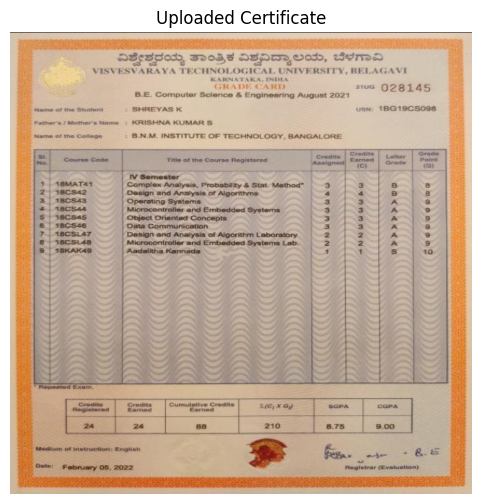


image 1/1 /content/f2_png.rf.3062df769512c99a34ea4019307c5646.jpg: 640x640 3 fakes, 11.4ms
Speed: 3.0ms preprocess, 11.4ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

Detected Regions:



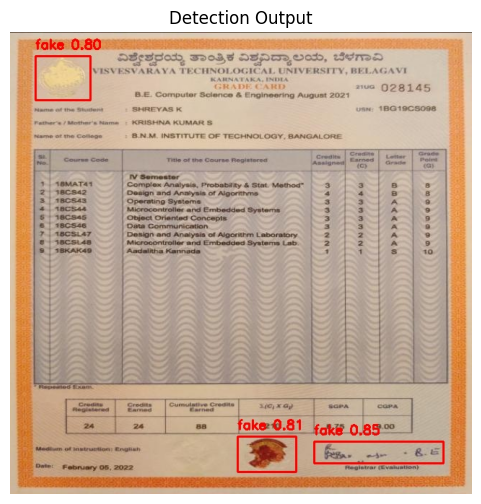


------------------------------------------------------------
   CERTIFICATE FORGERY DETECTION RESULT
------------------------------------------------------------

File            : f2_png.rf.3062df769512c99a34ea4019307c5646.jpg
Detected Regions: 3
Fake Regions    : 3
Prediction      : FAKE
Confidence      : 85.44 %
Status          : WARNING: Forgery Detected

------------------------------------------------------------


In [ ]:
from ultralytics import YOLO
import cv2
import os
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files

# ============================================================
# LOAD MODEL
# ============================================================

MODEL_PATH = "/content/drive/MyDrive/dissertration2/best (3).pt"
model = YOLO(MODEL_PATH)

# ============================================================
# DISPLAY IMAGE
# ============================================================

def display_image(image_path, title="Image"):
    img = Image.open(image_path)
    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.axis('off')
    plt.title(title)
    plt.show()

# ============================================================
# ANALYZE PREDICTIONS
# ============================================================

def analyze_predictions(results):
    fake_count = 0
    total = 0
    max_conf = 0
    most_suspicious = None

    for box in results.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        class_name = model.names[cls]

        total += 1

        if conf > max_conf:
            max_conf = conf
            most_suspicious = box

        if class_name == "fake":
            fake_count += 1

    return total, fake_count, max_conf, most_suspicious

# ============================================================
# DRAW BOXES + HIGHLIGHT MOST SUSPICIOUS
# ============================================================

def draw_boxes(image_path, results, most_suspicious):
    image = cv2.imread(image_path)

    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        class_name = model.names[cls]

        # Normal colors
        color = (0,255,0) if class_name == "true" else (0,0,255)

        # Highlight most suspicious
        if box is most_suspicious:
            color = (255,0,0)  # Blue (highlight)

        cv2.rectangle(image, (x1,y1), (x2,y2), color, 2)

        label = f"{class_name} {conf:.2f}"
        cv2.putText(image, label, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    output_path = "output.jpg"
    cv2.imwrite(output_path, image)
    return output_path

# ============================================================
# DISPLAY RESULT (ADVANCED CLEAN OUTPUT)
# ============================================================

def display_result(image_path, total, fake_count, max_conf):
    filename = os.path.basename(image_path)

    print("\n" + "-"*60)
    print("   CERTIFICATE FORGERY DETECTION RESULT")
    print("-"*60)

    print(f"\nFile            : {filename}")
    print(f"Detected Regions: {total}")
    print(f"Fake Regions    : {fake_count}")

    if fake_count > 0:
        prediction = "FAKE"
        status = "WARNING: Forgery Detected"
    else:
        prediction = "AUTHENTIC"
        status = "Verified"

    print(f"Prediction      : {prediction}")
    print(f"Confidence      : {max_conf*100:.2f} %")
    print(f"Status          : {status}")

    print("\n" + "-"*60)

# ============================================================
# MAIN INFERENCE
# ============================================================

def run_inference(image_path):

    print("\n" + "-"*60)
    print("           CERTIFICATE ANALYSIS")
    print("-"*60)

    display_image(image_path, "Uploaded Certificate")

    results = model.predict(image_path, conf=0.4)[0]

    # 🚨 FIX: NO DETECTION CASE
    if len(results.boxes) == 0:
        print("\n❌ No forgery-related regions detected.")
        print("⚠️ Unable to determine authenticity.\n")
        return

    # Analyze
    total, fake_count, max_conf, most_suspicious = analyze_predictions(results)

    # Draw boxes
    output_image = draw_boxes(image_path, results, most_suspicious)

    print("\nDetected Regions:\n")
    display_image(output_image, "Detection Output")

    # Show result
    display_result(image_path, total, fake_count, max_conf)

# ============================================================
# UPLOAD IMAGE
# ============================================================

print("\n" + "-"*60)
print("           UPLOAD CERTIFICATE IMAGE")
print("-"*60)

uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    print("\nFile uploaded successfully!\n")
    run_inference(filename)
else:
    print("No file uploaded.")

In [ ]:
!pip install inference-sdk
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv-python-4.13.0.92
  Attempting uninstall: aiohttp
    Found existing installation: aiohttp 3.13.3
    Uninstalling aiohttp-3.13.3:
      Successfully uninstalled aiohttp-3.13.3


##Roboflow


------------------------------------------------------------
           UPLOAD CERTIFICATE IMAGE
------------------------------------------------------------


Saving 81W5nfYYxoL-_AC_UF8941000_QL80__jpg.rf.3cd51166be3fc0e5e6b5ca009dc9e919.jpg to 81W5nfYYxoL-_AC_UF8941000_QL80__jpg.rf.3cd51166be3fc0e5e6b5ca009dc9e919.jpg

File uploaded successfully!



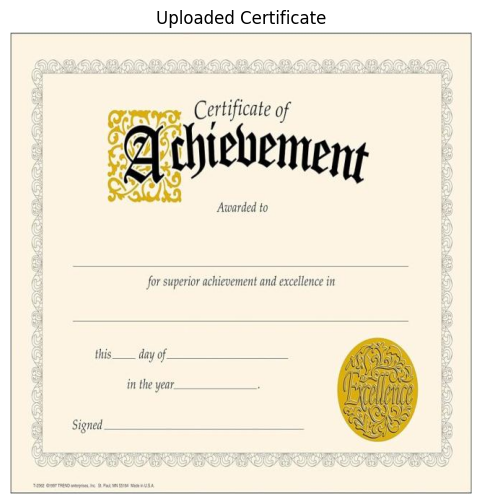


No regions detected.


------------------------------------------------------------
   CERTIFICATE FORGERY DETECTION RESULT
------------------------------------------------------------

File        : 81W5nfYYxoL-_AC_UF8941000_QL80__jpg.rf.3cd51166be3fc0e5e6b5ca009dc9e919.jpg
Prediction  : AUTHENTIC
Confidence  : 0.00 %
Status      : Verified

------------------------------------------------------------


In [ ]:
# =====================================================================
# CLEAN YOLO (ROBOFLOW) INFERENCE - TERMINAL VERSION
# =====================================================================

import os
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from inference_sdk import InferenceHTTPClient

# ============================================================
# ROBOFLOW CLIENT
# ============================================================

CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="Uaf3wrIGgqIklW4INFVf"
)

MODEL_ID = "certificate-forgery-detection-avxar/1"


# ============================================================
# DISPLAY IMAGE
# ============================================================

def display_image(image_path, title="Image"):
    image = Image.open(image_path)

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(title, fontsize=12)
    plt.show()


# ============================================================
# FINAL DECISION LOGIC
# ============================================================

def final_decision(predictions):
    fake_count = 0
    true_count = 0

    for pred in predictions:
        if pred['class'] == 'fake':
            fake_count += 1
        else:
            true_count += 1

    # Rule: if any fake detected -> FAKE
    if fake_count > 0:
        return "FAKE"
    else:
        return "AUTHENTIC"


# ============================================================
# DISPLAY RESULT
# ============================================================

def display_result(image_path, result_json):
    filename = os.path.basename(image_path)

    predictions = result_json.get('predictions', [])

    # Final decision
    final_result = final_decision(predictions)

    # Confidence (take highest)
    max_conf = 0
    for pred in predictions:
        if pred['confidence'] > max_conf:
            max_conf = pred['confidence']

    confidence = max_conf * 100

    print("\n" + "-"*60)
    print("   CERTIFICATE FORGERY DETECTION RESULT")
    print("-"*60)

    print(f"\nFile        : {filename}")
    print(f"Prediction  : {final_result}")
    print(f"Confidence  : {confidence:.2f} %")

    status = "WARNING: Forgery Detected" if final_result == "FAKE" else "Verified"
    print(f"Status      : {status}")

    print("\n" + "-"*60)


# ============================================================
# DRAW BOUNDING BOXES (OPTIONAL BUT GOOD FOR DEMO)
# ============================================================

def draw_boxes(image_path, predictions):
    image = cv2.imread(image_path)

    for pred in predictions:
        x = int(pred['x'])
        y = int(pred['y'])
        w = int(pred['width'])
        h = int(pred['height'])
        label = pred['class']
        conf = pred['confidence']

        # Convert center format to box
        x1 = int(x - w/2)
        y1 = int(y - h/2)
        x2 = int(x + w/2)
        y2 = int(y + h/2)

        color = (0, 255, 0) if label == "true" else (0, 0, 255)

        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, f"{label} {conf:.2f}",
                    (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, color, 2)

    output_path = "output.jpg"
    cv2.imwrite(output_path, image)

    return output_path


# ============================================================
# MAIN FLOW
# ============================================================

from google.colab import files

print("\n" + "-"*60)
print("           UPLOAD CERTIFICATE IMAGE")
print("-"*60)

uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]

    print("\nFile uploaded successfully!\n")

    # Show original image
    display_image(filename, "Uploaded Certificate")

    # ============================================================
    # PREDICT USING ROBOFLOW
    # ============================================================

    result = CLIENT.infer(filename, model_id=MODEL_ID)

    predictions = result.get("predictions", [])

    # ============================================================
    # DRAW DETECTIONS
    # ============================================================

    if len(predictions) > 0:
        output_image = draw_boxes(filename, predictions)

        print("\nDetected Regions:\n")
        display_image(output_image, "Forgery Detection Output")
    else:
        print("\nNo regions detected.\n")

    # ============================================================
    # FINAL RESULT
    # ============================================================

    display_result(filename, result)

else:
    print("No file uploaded. Please try again.")

🔍 CERTIFICATE FORGERY DETECTION - INFERENCE

📱 Device: cuda

📂 Loading model from: /content/drive/MyDrive/dissertration2/best_model.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Loaded checkpoint from epoch 5
   Validation Accuracy: 100.00%
✅ Model ready on cuda
✅ Model test passed! Output shape: torch.Size([1, 2])

------------------------------------------------------------
           UPLOAD CERTIFICATE IMAGE
------------------------------------------------------------


Saving f1_png.rf.68888f81db6f705688782c8e94829b5f.jpg to f1_png.rf.68888f81db6f705688782c8e94829b5f.jpg

File uploaded successfully!



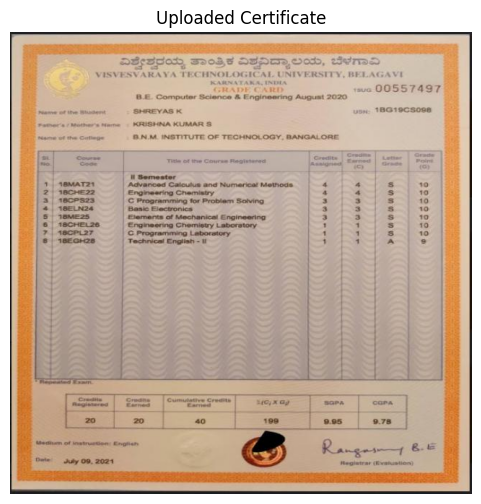


------------------------------------------------------------
   CERTIFICATE FORGERY DETECTION RESULT
------------------------------------------------------------

File        : f1_png.rf.68888f81db6f705688782c8e94829b5f.jpg
Prediction  : AUTHENTIC
Confidence  : 94.51 %
Status      : Verified

------------------------------------------------------------
Testing known images...
Fake image: {'prediction': 'AUTHENTIC', 'confidence': 94.50743198394775, 'model_confidence': 45.61108350753784, 'probabilities': array([0.05492573, 0.9450743 ], dtype=float32)}
Auth image: {'prediction': 'AUTHENTIC', 'confidence': 98.87009859085083, 'model_confidence': 43.1758314371109, 'probabilities': array([0.01129895, 0.988701  ], dtype=float32)}


In [ ]:
"""
CERTIFICATE FORGERY DETECTION - INFERENCE WITH IMAGE UPLOAD
Simple and efficient - matches your training exactly
"""

import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from PIL import Image, ImageChops, ImageEnhance

# ============================================================================
# CONFIGURATION - UPDATE THESE
# ============================================================================

MODEL_PATH = '/content/drive/MyDrive/dissertration2/best_model.pth'
IMAGE_SIZE = 640
USE_FORENSIC = True
USE_CPU = False  # Set True if CUDA issues

# ============================================================================
# FORENSIC ANALYZER (EXACT MATCH TO TRAINING)
# ============================================================================

class ForensicAnalyzer:
    @staticmethod
    def error_level_analysis(image, quality=90):
        if isinstance(image, np.ndarray):
            image = Image.fromarray(image)
        import io
        buffer = io.BytesIO()
        image.save(buffer, 'JPEG', quality=quality)
        buffer.seek(0)
        compressed = Image.open(buffer)
        ela_image = ImageChops.difference(image, compressed)
        extrema = ela_image.getextrema()
        max_diff = max([ex[1] for ex in extrema])
        if max_diff == 0:
            max_diff = 1
        scale = 255.0 / max_diff
        ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)
        return np.array(ela_image)

    @staticmethod
    def noise_analysis(image):
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image
        gaussian = cv2.GaussianBlur(gray, (0, 0), 3)
        noise = cv2.subtract(gray.astype(float), gaussian.astype(float))
        noise = np.abs(noise)
        noise = cv2.normalize(noise, None, 0, 255, cv2.NORM_MINMAX)
        return noise.astype(np.uint8)

    @staticmethod
    def edge_analysis(image):
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        else:
            gray = image
        edges1 = cv2.Canny(gray, 50, 150)
        edges2 = cv2.Canny(gray, 100, 200)
        edges = cv2.bitwise_or(edges1, edges2)
        kernel = np.ones((3, 3), np.uint8)
        edges = cv2.dilate(edges, kernel, iterations=1)
        return edges

    @staticmethod
    def create_forensic_features(image):
        """EXACTLY 3 CHANNELS - matches training"""
        if isinstance(image, Image.Image):
            image = np.array(image)

        ela = ForensicAnalyzer.error_level_analysis(image)
        noise = ForensicAnalyzer.noise_analysis(image)
        edges = ForensicAnalyzer.edge_analysis(image)

        # Convert to grayscale if needed
        if len(ela.shape) == 3:
            ela = cv2.cvtColor(ela, cv2.COLOR_RGB2GRAY)
        if len(noise.shape) == 3:
            noise = cv2.cvtColor(noise, cv2.COLOR_RGB2GRAY)
        if len(edges.shape) == 3:
            edges = cv2.cvtColor(edges, cv2.COLOR_RGB2GRAY)

        # Stack as 3-channel
        forensic_features = np.stack([ela, noise, edges], axis=-1)
        return forensic_features

# ============================================================================
# MODEL ARCHITECTURE (EXACT MATCH TO TRAINING)
# ============================================================================

class ForensicCNN(nn.Module):
    def __init__(self, num_classes=2, use_forensic=True):
        super(ForensicCNN, self).__init__()
        self.use_forensic = use_forensic

        # RGB stream
        self.rgb_backbone = models.efficientnet_b0(pretrained=False)
        rgb_features = self.rgb_backbone.classifier[1].in_features
        self.rgb_backbone.classifier = nn.Identity()

        # Forensic stream
        if use_forensic:
            self.forensic_stream = nn.Sequential(
                nn.Conv2d(3, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Conv2d(64, 128, kernel_size=3, padding=1),
                nn.BatchNorm2d(128),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Conv2d(128, 256, kernel_size=3, padding=1),
                nn.BatchNorm2d(256),
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d((1, 1))
            )
            combined_features = rgb_features + 256
        else:
            combined_features = rgb_features

        # Fusion layers
        self.fusion = nn.Sequential(
            nn.Linear(combined_features, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
        )

        # Classification head
        self.classifier = nn.Linear(256, num_classes)

        # Auxiliary outputs
        self.forgery_type_classifier = nn.Linear(256, 5)
        self.confidence_regressor = nn.Linear(256, 1)

    def forward(self, x):
        if self.use_forensic:
            rgb = x[:, :3, :, :]
            forensic = x[:, 3:, :, :]

            rgb_features = self.rgb_backbone(rgb)
            forensic_features = self.forensic_stream(forensic)
            forensic_features = forensic_features.view(forensic_features.size(0), -1)

            combined = torch.cat([rgb_features, forensic_features], dim=1)
        else:
            combined = self.rgb_backbone(x)

        fused = self.fusion(combined)

        class_output = self.classifier(fused)
        forgery_type = self.forgery_type_classifier(fused)
        confidence = torch.sigmoid(self.confidence_regressor(fused))

        return {
            'class': class_output,
            'forgery_type': forgery_type,
            'confidence': confidence,
            'features': fused
        }

# ============================================================================
# PREPROCESSING
# ============================================================================

def preprocess_image(image_path):
    """Load and preprocess image"""
    # Load image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize
    image_resized = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

    if USE_FORENSIC:
        # Create forensic features
        forensic_features = ForensicAnalyzer.create_forensic_features(image_resized)

        # Normalize RGB
        rgb_normalized = image_resized.astype(np.float32) / 255.0
        rgb_normalized = (rgb_normalized - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
        rgb_tensor = torch.from_numpy(rgb_normalized.transpose(2, 0, 1)).float()

        # Normalize forensic
        forensic_normalized = forensic_features.astype(np.float32) / 255.0
        forensic_tensor = torch.from_numpy(forensic_normalized.transpose(2, 0, 1)).float()

        # Combine: 3 RGB + 3 Forensic = 6 channels
        combined_tensor = torch.cat([rgb_tensor, forensic_tensor], dim=0)
        return combined_tensor.unsqueeze(0)
    else:
        # RGB only
        rgb_normalized = image_resized.astype(np.float32) / 255.0
        rgb_normalized = (rgb_normalized - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]
        rgb_tensor = torch.from_numpy(rgb_normalized.transpose(2, 0, 1)).float()
        return rgb_tensor.unsqueeze(0)

# ============================================================================
# INFERENCE
# ============================================================================

def predict(image_path):
    """Main prediction function"""
    # Preprocess
    input_tensor = preprocess_image(image_path)
    input_tensor = input_tensor.to(device)

    # Predict
    with torch.no_grad():
        outputs = model(input_tensor)

        # Get class prediction
        class_logits = outputs['class']
        probs = F.softmax(class_logits, dim=1)
        pred_class = class_logits.argmax(1).item()
        confidence = probs[0, pred_class].item() * 100

        # Get model's internal confidence
        model_confidence = outputs['confidence'].item() * 100

    # Class names
    class_names = ['FAKE', 'AUTHENTIC']
    prediction = class_names[pred_class]

    return {
        'prediction': prediction,
        'confidence': confidence,
        'model_confidence': model_confidence,
        'probabilities': probs[0].cpu().numpy()
    }

# ============================================================================
# LOAD MODEL
# ============================================================================

print("="*70)
print("🔍 CERTIFICATE FORGERY DETECTION - INFERENCE")
print("="*70)

# Set device
device = torch.device('cpu' if USE_CPU else ('cuda' if torch.cuda.is_available() else 'cpu'))
print(f"\n📱 Device: {device}")

# Load model
print(f"\n📂 Loading model from: {MODEL_PATH}")

model = ForensicCNN(num_classes=2, use_forensic=USE_FORENSIC)

checkpoint = torch.load(MODEL_PATH, map_location='cpu')

if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Loaded checkpoint from epoch {checkpoint.get('epoch', '?')}")
    if 'val_acc' in checkpoint:
        print(f"   Validation Accuracy: {checkpoint['val_acc']:.2f}%")
else:
    model.load_state_dict(checkpoint)
    print("✅ Loaded model weights")

model = model.to(device)
model.eval()

print(f"✅ Model ready on {device}")

# Test
test_input = torch.randn(1, 6 if USE_FORENSIC else 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
with torch.no_grad():
    test_output = model(test_input)
print(f"✅ Model test passed! Output shape: {test_output['class'].shape}")

# =====================================================================
# CLEAN UPLOAD + DISPLAY + RESULT (TERMINAL FRIENDLY)
# =====================================================================

import os
import matplotlib.pyplot as plt
from PIL import Image

def display_image(image_path):
    """Display uploaded image cleanly"""
    image = Image.open(image_path)

    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title("Uploaded Certificate", fontsize=12)
    plt.show()


def display_result(image_path, result):
    """Clean formatted output"""
    filename = os.path.basename(image_path)

    print("\n" + "-"*60)
    print("   CERTIFICATE FORGERY DETECTION RESULT")
    print("-"*60)

    print(f"\nFile        : {filename}")
    print(f"Prediction  : {result['prediction']}")
    print(f"Confidence  : {result['confidence']:.2f} %")

    status = "WARNING: Forgery Detected" if result['prediction'] == "FAKE" else "Verified"
    print(f"Status      : {status}")

    print("\n" + "-"*60)


# =====================================================================
# UPLOAD SECTION (CLEAN)
# =====================================================================

from google.colab import files

print("\n" + "-"*60)
print("           UPLOAD CERTIFICATE IMAGE")
print("-"*60)

uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]

    print("\nFile uploaded successfully!\n")

    # Show image
    display_image(filename)

    # Prediction
    result = predict(filename)

    # Show result
    display_result(filename, result)
print("Testing known images...")

fake_test = "/content/f1_png.rf.2679b85f2ffe3f0f1506126d4f8a0fba (1).jpg"
auth_test = "/content/Upto-4th-Sem-Markscard_page-0002_jpg.rf.0d819041ec1c1b69dc109cd0ade8efdb.jpg"

print("Fake image:", predict(fake_test))
print("Auth image:", predict(auth_test))



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# object Detection System

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup complete!

📂 Loading trained model from Google Drive...
🖥️ Using device: cuda
✅ Model loaded successfully!
📊 Detected classes: ['signature', 'stamp', 'degree', 'all']
🎯 Number of classes: 4

📤 UPLOAD YOUR DOCUMENT IMAGES


Saving 36_png.rf.28ce00c7c32d23cc0b51946d7d8c565d.jpg to 36_png.rf.28ce00c7c32d23cc0b51946d7d8c565d.jpg
✅ Uploaded 1 file(s)


📸 PROCESSING: 36_png.rf.28ce00c7c32d23cc0b51946d7d8c565d.jpg

✨ Step 1: Displaying original image...


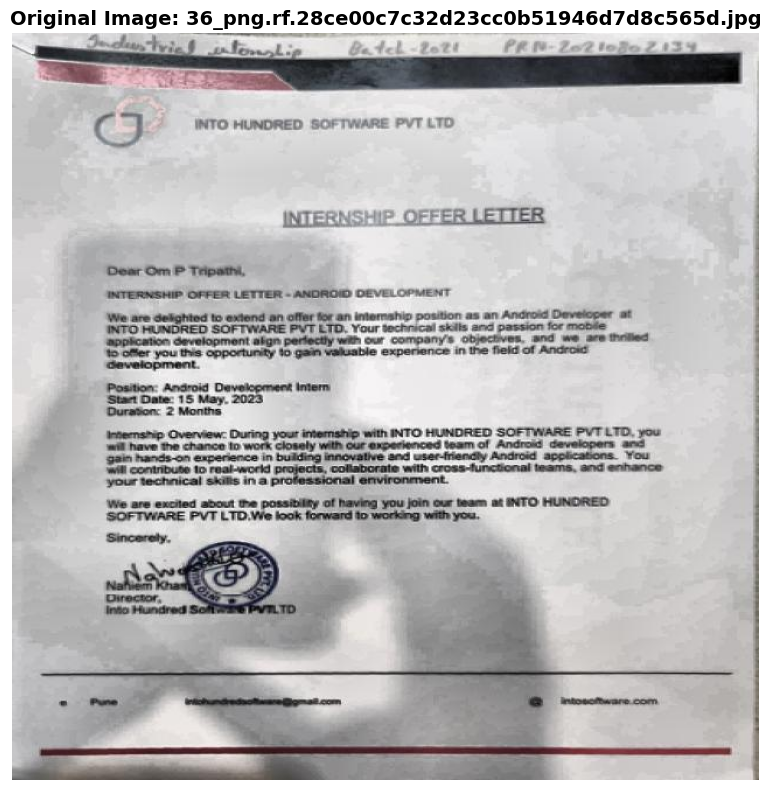


🔍 Step 2: Running YOLO detection...

📊 Step 3: Displaying detection results...


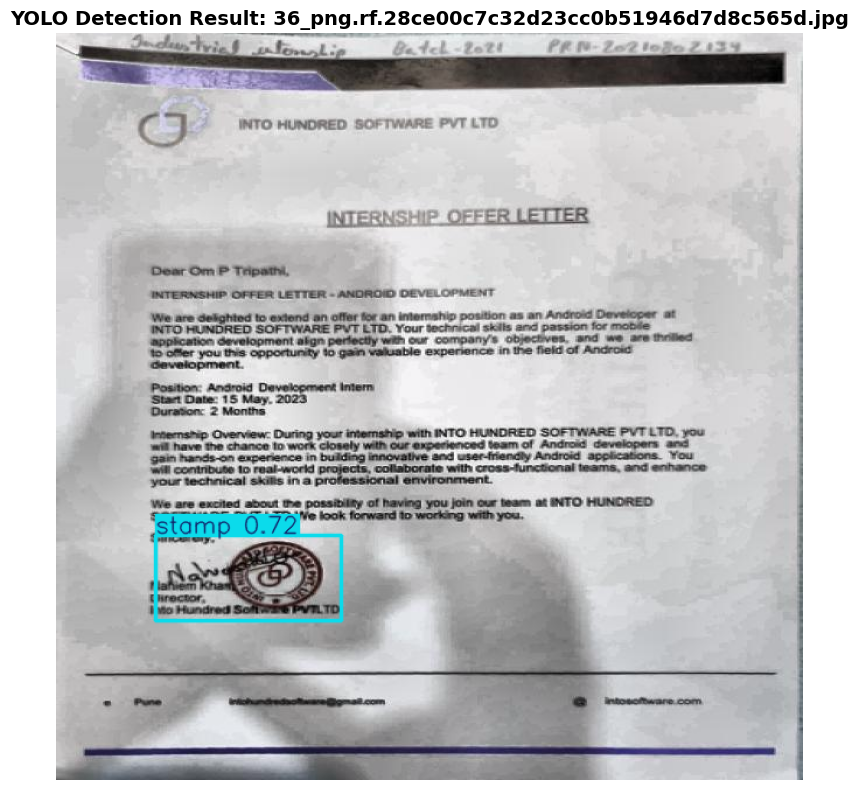


📋 DETECTION RESULTS
✅ FOUND 1 OBJECT(S):

  1. STAMP
     Confidence: 72.2%
     Location: [85, 430, 244, 503]

📊 SUMMARY
Total detections: 1
Detected object types: ['stamp']


💡 TIPS FOR BETTER DETECTION

1. Adjust confidence threshold:
   • conf=0.10-0.20: Loose (more detections, may have false positives)
   • conf=0.25-0.30: Balanced (recommended) ✅
   • conf=0.40-0.60: Strict (only high-confidence detections)

2. Current model performance:
   • Your model accuracy: 56.4% mAP50
   • To improve: Use YOLOv8s with 200 epochs (see optimized training code)

3. Best practices:
   • Use clear, well-lit document images
   • Avoid blurry or low-resolution images
   • Ensure objects are clearly visible

✅ INFERENCE COMPLETE!


In [ ]:
"""
Document Object Detection - Clean Inference
Detects: Signature, Stamp, Degree text
Upload images → Detect → Show results
Model embedded in code - no model upload needed
"""

# ============================================================================
# STEP 1: SETUP & MOUNT GOOGLE DRIVE
# ============================================================================
from google.colab import drive, files
drive.mount('/content/drive')

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import io
from PIL import Image, UnidentifiedImageError
import torch
from ultralytics import YOLO

print("✅ Setup complete!")

# ============================================================================
# STEP 2: LOAD YOLO MODEL (FROM GOOGLE DRIVE)
# ============================================================================
print("\n📂 Loading trained model from Google Drive...")

# 🔥 UPDATE THIS PATH TO YOUR MODEL LOCATION 🔥
MODEL_PATH = "/content/drive/MyDrive/dissertration2/merged_best_62.5%.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️ Using device: {device}")

model = YOLO(MODEL_PATH)
model.to(device)

# Model info
LABELS = list(model.names.values())
print(f"✅ Model loaded successfully!")
print(f"📊 Detected classes: {LABELS}")
print(f"🎯 Number of classes: {len(LABELS)}")

# ============================================================================
# STEP 3: UPLOAD TEST IMAGES
# ============================================================================
print("\n" + "="*70)
print("📤 UPLOAD YOUR DOCUMENT IMAGES")
print("="*70)

uploaded = files.upload()

if not uploaded:
    print("⚠️ No file uploaded.")
else:
    print(f"✅ Uploaded {len(uploaded)} file(s)\n")

# ============================================================================
# STEP 4: PROCESS EACH IMAGE
# ============================================================================
if uploaded:
    for filename in uploaded.keys():
        try:
            print("\n" + "="*70)
            print(f"📸 PROCESSING: {filename}")
            print("="*70)

            # Load image
            img_pil = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')
            image_np = np.array(img_pil).astype(np.uint8)

            # ---------- DISPLAY ORIGINAL IMAGE ----------
            print("\n✨ Step 1: Displaying original image...")
            plt.figure(figsize=(10, 8))
            plt.imshow(image_np)
            plt.title(f"Original Image: {filename}", fontsize=14, fontweight='bold')
            plt.axis('off')
            plt.tight_layout()
            plt.show()

            # ---------- RUN YOLO DETECTION ----------
            print("\n🔍 Step 2: Running YOLO detection...")

            # Detection configuration
            CONF_THRESHOLD = 0.10  # Confidence threshold (adjust if needed)
            IOU_THRESHOLD = 0.30   # IoU threshold for NMS

            results = model.predict(
                image_np,
                conf=CONF_THRESHOLD,
                iou=IOU_THRESHOLD,
                device=device,
                verbose=False
            )

            boxes = results[0].boxes

            # ---------- DISPLAY DETECTED IMAGE ----------
            print("\n📊 Step 3: Displaying detection results...")

            # Get annotated image
            result_img_bgr = results[0].plot()
            result_img_rgb = cv.cvtColor(result_img_bgr, cv.COLOR_BGR2RGB)

            plt.figure(figsize=(10, 8))
            plt.imshow(result_img_rgb)
            plt.title(f"YOLO Detection Result: {filename}", fontsize=14, fontweight='bold')
            plt.axis('off')
            plt.tight_layout()
            plt.show()

            # ---------- PRINT DETECTED OBJECTS ----------
            print("\n" + "="*70)
            print("📋 DETECTION RESULTS")
            print("="*70)

            if len(boxes) > 0:
                print(f"✅ FOUND {len(boxes)} OBJECT(S):\n")

                detected_classes = []
                for i, box in enumerate(boxes, 1):
                    cls_id = int(box.cls[0])
                    confidence = float(box.conf[0])
                    class_name = LABELS[cls_id]
                    bbox = box.xyxy[0].cpu().numpy()

                    detected_classes.append(class_name)

                    print(f"  {i}. {class_name.upper()}")
                    print(f"     Confidence: {confidence*100:.1f}%")
                    print(f"     Location: [{int(bbox[0])}, {int(bbox[1])}, {int(bbox[2])}, {int(bbox[3])}]")
                    print()

                # Summary
                print("="*70)
                print("📊 SUMMARY")
                print("="*70)
                print(f"Total detections: {len(boxes)}")
                print(f"Detected object types: {list(set(detected_classes))}")
                print()

            else:
                print("❌ NO OBJECTS DETECTED")
                print(f"   Current confidence threshold: {CONF_THRESHOLD}")
                print("   💡 Try lowering the threshold (e.g., 0.15 or 0.10)")
                print()

        except UnidentifiedImageError:
            print(f"⚠️ File '{filename}' is not a valid image.")
            print("   Please upload JPG, PNG, or JPEG files.")

        except Exception as e:
            print(f"❌ Error processing '{filename}': {str(e)}")

# ============================================================================
# STEP 5: DETECTION STATISTICS (IF MULTIPLE IMAGES)
# ============================================================================
if uploaded and len(uploaded) > 1:
    print("\n" + "="*70)
    print("📊 OVERALL STATISTICS")
    print("="*70)

    total_detections = 0
    class_counts = {label: 0 for label in LABELS}
    confidence_scores = []

    for filename in uploaded.keys():
        try:
            img_pil = Image.open(io.BytesIO(uploaded[filename])).convert('RGB')
            image_np = np.array(img_pil).astype(np.uint8)

            results = model.predict(image_np, conf=0.25, device=device, verbose=False)
            boxes = results[0].boxes

            for box in boxes:
                cls_id = int(box.cls[0])
                conf = float(box.conf[0])
                class_name = LABELS[cls_id]

                class_counts[class_name] += 1
                total_detections += 1
                confidence_scores.append(conf)
        except:
            continue

    print(f"Total images processed: {len(uploaded)}")
    print(f"Total objects detected: {total_detections}")

    if confidence_scores:
        avg_conf = sum(confidence_scores) / len(confidence_scores)
        print(f"Average confidence: {avg_conf*100:.1f}%")

        print(f"\nDetections by class:")
        for class_name, count in class_counts.items():
            if count > 0:
                print(f"  • {class_name}: {count}")

# ============================================================================
# STEP 6: TIPS & NOTES
# ============================================================================
print("\n" + "="*70)
print("💡 TIPS FOR BETTER DETECTION")
print("="*70)
print("\n1. Adjust confidence threshold:")
print("   • conf=0.10-0.20: Loose (more detections, may have false positives)")
print("   • conf=0.25-0.30: Balanced (recommended) ✅")
print("   • conf=0.40-0.60: Strict (only high-confidence detections)")

print("\n2. Current model performance:")
print("   • Your model accuracy: 56.4% mAP50")
print("   • To improve: Use YOLOv8s with 200 epochs (see optimized training code)")

print("\n3. Best practices:")
print("   • Use clear, well-lit document images")
print("   • Avoid blurry or low-resolution images")
print("   • Ensure objects are clearly visible")

print("\n" + "="*70)
print("✅ INFERENCE COMPLETE!")
print("="*70)
